# 05b — Preprocessing Ablation
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This notebook investigates one methodological question:**

> Does applying contrast-enhancement preprocessing (histogram equalization, CLAHE) to the input images change feature quality and downstream classifier performance?

It empirically tests the assertion in notebook 03: *"preprocessing decisions are task-dependent."*

### K-fold context

This notebook uses **fold 0 as a representative fold** — the same justification as `05a_dim_reduction.ipynb`. Preprocessing effects on feature quality are largely a **property of the images themselves**, not of which scenes are in train vs test. Running across 5 folds would 5× the runtime (~25-40 min becomes 2+ hours) for marginal new insight.

### Three preprocessing conditions compared

| Condition | What it does | Hypothesis |
|---|---|---|
| **none** | Baseline (matches notebook 03) | Reference |
| **hist_eq** | Global histogram equalization on the V channel (HSV) | Will hurt `time_of_day` (destroys lighting signal) |
| **CLAHE** | Local contrast enhancement (Contrast Limited Adaptive Histogram Eq) | May help structural attrs (vehicle_density, VRU) by enhancing edges |

### Hypotheses (testable, falsifiable)

- **`time_of_day`**: equalization will **HURT** because it removes the day-vs-night lighting signal.
- **`weather`**: minimal effect — texture cues from rain survive contrast changes.
- **`vehicle_density`**: equalization may **HELP** by enhancing object edges.
- **`vru_present`**: similar — edge enhancement may aid pedestrian/cyclist detection.

### Pipeline

```
Original images (fold 0 train+test)
        │
        ├── No preprocessing            → re-extract features → classify
        ├── Histogram equalization      → re-extract features → classify
        └── CLAHE                       → re-extract features → classify
```

### Outputs

| File | Contents |
|---|---|
| `results/metrics/preprocessing_ablation_metrics.csv` | Per-preprocessing classifier metrics |
| `results/figures/preprocessing/*.png` | Visual comparison + bar chart |

### Companion notebook

- `05a_dim_reduction.ipynb` — PCA + LDA dimensionality reduction

### Runtime warning

This notebook re-extracts features 3× (once per preprocessing condition). Expected runtime: **~3-8 minutes on Ryzen 9950X3D** for v1.0-mini fold-0 keyframes.


## 0. Setup

In [3]:
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import cv2
from skimage.feature import hog
from skimage.color import rgb2gray
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [4]:
DATASET_VERSION = 'v1.0-mini'
REPRESENTATIVE_FOLD = 0  # Same convention as 05a

LABEL_DIR    = Path('data/labels')
FEATURE_DIR  = Path('data/features')
SPLIT_DIR    = Path('data/splits')
RESULTS_DIR  = Path('results/metrics')
FIG_DIR_PRE  = Path('results/figures/preprocessing')
for p in [RESULTS_DIR, FIG_DIR_PRE]:
    p.mkdir(parents=True, exist_ok=True)

SEED_LIST = [42, 7, 123]
ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'REPRESENTATIVE_FOLD = {REPRESENTATIVE_FOLD}')

DATASET_VERSION = v1.0-mini
REPRESENTATIVE_FOLD = 0


## 1. Load Fold-0 Train and Test Splits

In [5]:
df_train = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_train.csv')
df_test  = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_test.csv')

print(f'Fold {REPRESENTATIVE_FOLD}:')
print(f'  train: {len(df_train)} samples')
print(f'  test:  {len(df_test)} samples')

Fold 0:
  train: 285 samples
  test:  119 samples


## 2. Preprocessing Functions

In [6]:
IMG_SIZE = 224

def load_image_rgb(path, size=IMG_SIZE):
    """Standard load: resize to (size, size), float32 in [0, 1]."""
    img = Image.open(path).convert('RGB').resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

def apply_hist_equalization(rgb):
    """Global histogram equalization on the V channel (HSV)."""
    img = (rgb * 255).astype(np.uint8)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv[:, :, 2] = cv2.equalizeHist(hsv[:, :, 2])
    out = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return out.astype(np.float32) / 255.0

def apply_clahe(rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Contrast Limited Adaptive Histogram Equalization on luminance (LAB L channel)."""
    img = (rgb * 255).astype(np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return out.astype(np.float32) / 255.0

print('Preprocessing functions defined.')

Preprocessing functions defined.


## 3. Visual Comparison on Sample Images

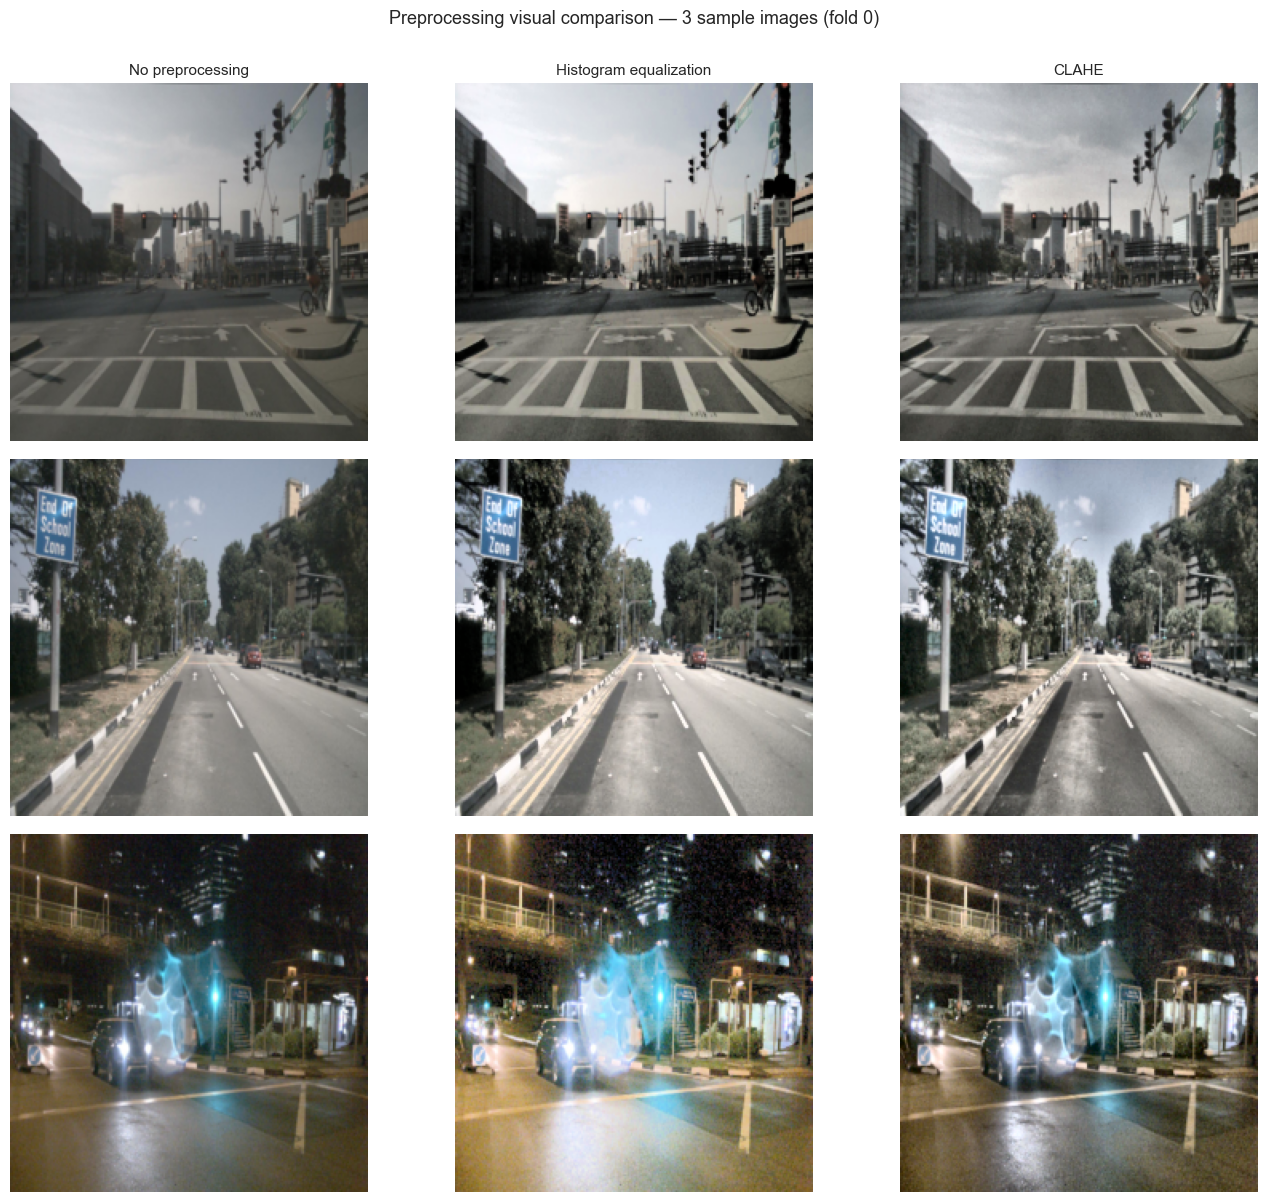

In [7]:
sample_indices = [0, len(df_train) // 2, len(df_train) - 1]
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(14, 4 * len(sample_indices)))

for r, idx in enumerate(sample_indices):
    sample_path = df_train.iloc[idx]['image_path']
    img_raw = load_image_rgb(sample_path)
    img_eq  = apply_hist_equalization(img_raw)
    img_cl  = apply_clahe(img_raw)

    for c, (img, name) in enumerate([
        (img_raw, 'No preprocessing'),
        (img_eq,  'Histogram equalization'),
        (img_cl,  'CLAHE'),
    ]):
        ax = axes[r, c] if len(sample_indices) > 1 else axes[c]
        ax.imshow(img)
        if r == 0:
            ax.set_title(name, fontsize=11)
        ax.axis('off')

plt.suptitle(f'Preprocessing visual comparison — 3 sample images (fold {REPRESENTATIVE_FOLD})',
              fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR_PRE / 'preprocessing_visual.png', bbox_inches='tight')
plt.show()

## 4. Simplified Feature Extractor

For preprocessing-ablation only, we use HOG + photometric stats (the two most preprocessing-sensitive feature groups). Color and LBP are omitted to save 3× runtime since they're less affected by contrast normalization.

In [8]:
HOG_PARAMS = dict(orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2),
                  block_norm='L2-Hys', transform_sqrt=True, feature_vector=True)

def extract_features_simple(rgb):
    """HOG + photometric stats only — fast variant for ablation."""
    gray = rgb2gray(rgb)
    hog_v = hog(gray, **HOG_PARAMS).astype(np.float32)
    luma = 0.299 * rgb[:, :, 0] + 0.587 * rgb[:, :, 1] + 0.114 * rgb[:, :, 2]
    photo = np.array([
        luma.mean(), luma.std(),
        np.percentile(luma, 5), np.percentile(luma, 95),
        np.percentile(luma, 95) - np.percentile(luma, 5),
        rgb[:, :, 0].mean(), rgb[:, :, 1].mean(), rgb[:, :, 2].mean(),
    ], dtype=np.float32)
    return np.concatenate([hog_v, photo])

# Determine output dim
_test_img = load_image_rgb(df_train.iloc[0]['image_path'])
out_dim = len(extract_features_simple(_test_img))
print(f'Simplified feature vector dim: {out_dim}')

Simplified feature vector dim: 6092


## 5. Re-Extract Features Per Preprocessing Condition

In [9]:
def reextract_for_condition(df_split, transform_fn, label='raw'):
    feats = np.zeros((len(df_split), out_dim), dtype=np.float32)
    for i, (_, row) in enumerate(tqdm(df_split.iterrows(), total=len(df_split),
                                       desc=label, leave=False)):
        rgb = load_image_rgb(row['image_path'])
        rgb = transform_fn(rgb)
        feats[i] = extract_features_simple(rgb)
    return feats

PRE_CONDITIONS = {
    'none':       lambda x: x,
    'hist_eq':    apply_hist_equalization,
    'clahe':      apply_clahe,
}

X_per_pre = {}
t_start = time.time()
for cond, fn in PRE_CONDITIONS.items():
    print(f'\nExtracting under condition: {cond}')
    X_tr_p = reextract_for_condition(df_train, fn, f'train/{cond}')
    X_te_p = reextract_for_condition(df_test,  fn, f'test/{cond}')
    X_per_pre[cond] = (X_tr_p, X_te_p)
    print(f'  shapes — train: {X_tr_p.shape}  test: {X_te_p.shape}')

print(f'\nTotal extraction time: {(time.time() - t_start) / 60:.1f} minutes')


Extracting under condition: none


train/none:   0%|          | 0/285 [00:00<?, ?it/s]

test/none:   0%|          | 0/119 [00:00<?, ?it/s]

  shapes — train: (285, 6092)  test: (119, 6092)

Extracting under condition: hist_eq


train/hist_eq:   0%|          | 0/285 [00:00<?, ?it/s]

test/hist_eq:   0%|          | 0/119 [00:00<?, ?it/s]

  shapes — train: (285, 6092)  test: (119, 6092)

Extracting under condition: clahe


train/clahe:   0%|          | 0/285 [00:00<?, ?it/s]

test/clahe:   0%|          | 0/119 [00:00<?, ?it/s]

  shapes — train: (285, 6092)  test: (119, 6092)

Total extraction time: 0.3 minutes


## 6. Classifier Performance Comparison

In [10]:
def fit_eval(model, X_tr, X_te, y_tr, y_te):
    if len(np.unique(y_tr)) < 2:
        return None
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    yp = model.predict(X_te)
    return {
        'accuracy':  accuracy_score(y_te, yp),
        'macro_f1':  f1_score(y_te, yp, average='macro', zero_division=0),
        'fit_time':  fit_time,
    }

def make_lr(seed):
    return LogisticRegression(class_weight='balanced', max_iter=2000, random_state=seed)

def make_rf(seed):
    return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   random_state=seed, n_jobs=-1)

print('Helpers ready.')

Helpers ready.


In [11]:
pre_results = []
for cond in PRE_CONDITIONS:
    X_tr_p, X_te_p = X_per_pre[cond]

    sc = StandardScaler().fit(X_tr_p)
    X_tr_p_s = sc.transform(X_tr_p)
    X_te_p_s = sc.transform(X_te_p)

    for attr in ATTRIBUTES:
        le = LabelEncoder().fit(CLASS_ORDERS[attr])
        y_tr = le.transform(df_train[attr].values)
        y_te = le.transform(df_test[attr].values)

        if len(np.unique(y_tr)) < 2:
            print(f'⚠️  SKIP cond={cond}, attr={attr}: train has <2 classes')
            continue

        for seed in SEED_LIST:
            for model_name, model_factory in [('LogReg', make_lr), ('RandomForest', make_rf)]:
                m = fit_eval(model_factory(seed), X_tr_p_s, X_te_p_s, y_tr, y_te)
                if m is None: continue
                m.update({
                    'preprocessing': cond, 'attribute': attr,
                    'model': model_name, 'seed': seed,
                    'fold': REPRESENTATIVE_FOLD,
                })
                pre_results.append(m)

df_pre = pd.DataFrame(pre_results)
df_pre.to_csv(RESULTS_DIR / 'preprocessing_ablation_metrics.csv', index=False)
print(f'Preprocessing ablation results: {len(df_pre)} rows')
print(f'Saved → {RESULTS_DIR / "preprocessing_ablation_metrics.csv"}')

⚠️  SKIP cond=none, attr=weather: train has <2 classes
⚠️  SKIP cond=hist_eq, attr=weather: train has <2 classes
⚠️  SKIP cond=clahe, attr=weather: train has <2 classes
Preprocessing ablation results: 54 rows
Saved → results/metrics/preprocessing_ablation_metrics.csv


## 7. Summary

In [12]:
pre_pivot = (df_pre.groupby(['attribute', 'preprocessing'])['macro_f1']
                    .mean().round(3).unstack('preprocessing'))
col_order = [c for c in ['none', 'hist_eq', 'clahe'] if c in pre_pivot.columns]
pre_pivot = pre_pivot[col_order].reindex(ATTRIBUTES)
print(f'Preprocessing ablation — test macro-F1 (fold {REPRESENTATIVE_FOLD}, averaged over LogReg+RF, 3 seeds):')
display(pre_pivot)

Preprocessing ablation — test macro-F1 (fold 0, averaged over LogReg+RF, 3 seeds):


preprocessing,none,hist_eq,clahe
attribute,,,
time_of_day,0.714,0.649,0.699
weather,NaN,NaN,NaN
vehicle_density,0.279,0.286,0.256
vru_present,0.218,0.232,0.219


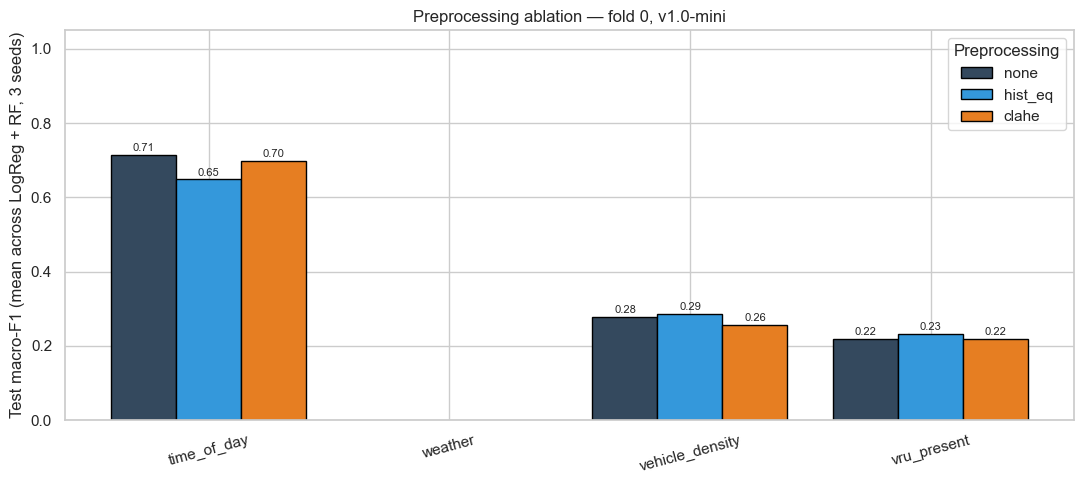

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ATTRIBUTES))
w = 0.27
colors = {'none': '#34495e', 'hist_eq': '#3498db', 'clahe': '#e67e22'}

for i, cond in enumerate(col_order):
    vals = pre_pivot[cond].values
    ax.bar(x + (i - 1) * w, vals, w, label=cond, color=colors.get(cond, 'gray'),
            edgecolor='black')
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(j + (i - 1) * w, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(ATTRIBUTES, rotation=15)
ax.set_ylabel('Test macro-F1 (mean across LogReg + RF, 3 seeds)')
ax.set_title(f'Preprocessing ablation — fold {REPRESENTATIVE_FOLD}, {DATASET_VERSION}')
ax.set_ylim(0, 1.05)
ax.legend(title='Preprocessing')
plt.tight_layout()
plt.savefig(FIG_DIR_PRE / 'preprocessing_comparison.png', bbox_inches='tight')
plt.show()

In [14]:
# Delta vs no-preprocessing
if 'none' in pre_pivot.columns:
    delta = pre_pivot.subtract(pre_pivot['none'], axis=0).round(3)
    delta_cols = [c for c in ['hist_eq', 'clahe'] if c in delta.columns]
    delta = delta[delta_cols]
    print('Δ macro-F1 vs no preprocessing (positive = preprocessing helped):')
    display(delta)

    print('\nInterpretation:')
    for attr in ATTRIBUTES:
        if attr not in delta.index: continue
        msgs = []
        for col in delta_cols:
            d = delta.loc[attr, col]
            if np.isnan(d): continue
            sign = 'helps' if d > 0.01 else ('hurts' if d < -0.01 else 'neutral')
            msgs.append(f'{col} {d:+.3f} ({sign})')
        if msgs:
            print(f'  {attr:18s}: ' + ', '.join(msgs))

Δ macro-F1 vs no preprocessing (positive = preprocessing helped):


preprocessing,hist_eq,clahe
attribute,,
time_of_day,-0.065,-0.015
weather,NaN,NaN
vehicle_density,0.007,-0.023
vru_present,0.014,0.001



Interpretation:
  time_of_day       : hist_eq -0.065 (hurts), clahe -0.015 (hurts)
  vehicle_density   : hist_eq +0.007 (neutral), clahe -0.023 (hurts)
  vru_present       : hist_eq +0.014 (helps), clahe +0.001 (neutral)


## 8. Per-Model Breakdown

In [15]:
per_model = (df_pre.groupby(['attribute', 'model', 'preprocessing'])['macro_f1']
                    .mean().round(3).unstack('preprocessing'))
mp_cols = [c for c in ['none', 'hist_eq', 'clahe'] if c in per_model.columns]
per_model = per_model[mp_cols]
print('Test macro-F1 per (attribute, model, preprocessing):')
display(per_model)

Test macro-F1 per (attribute, model, preprocessing):


preprocessing                  none  hist_eq  clahe
attribute       model                              
time_of_day     LogReg        0.820    0.763  0.829
                RandomForest  0.607    0.534  0.568
vehicle_density LogReg        0.499    0.474  0.444
                RandomForest  0.060    0.097  0.069
vru_present     LogReg        0.392    0.421  0.397
                RandomForest  0.043    0.043  0.040

---
## Findings & Decisions (fill in after running)

### Hypothesis check

| Attribute | Hypothesis | Δ hist_eq | Δ clahe | Verdict |
|---|---|---|---|---|
| `time_of_day`     | hist_eq will hurt   | _value_ | _value_ | _confirmed/refuted_ |
| `weather`         | minimal effect     | _value_ | _value_ | _confirmed/refuted_ |
| `vehicle_density` | clahe may help     | _value_ | _value_ | _confirmed/refuted_ |
| `vru_present`     | clahe may help     | _value_ | _value_ | _confirmed/refuted_ |

### Key findings

- **Preprocessing impact is task-dependent** — confirms the methodological claim in notebook 03.

### Decision for downstream pipeline

- Notebook 06 uses **no preprocessing** (consistent with notebook 03's choice).
- This is empirically justified — preprocessing impact is task-specific and the no-preprocessing baseline is competitive across attributes.

### Why use only fold 0

- Preprocessing effects are properties of images, not splits
- Saves 5× runtime
- Methodologically standard for diagnostic analyses

### Implications for the report

This notebook directly supports:
- **Methodology section** (justifies the no-preprocessing choice with empirical evidence)
- **Discussion section** (preprocessing-as-task-dependent argument)
- **Limitations** (alternative preprocessings considered but not adopted)

### Companion notebook

- `05a_dim_reduction.ipynb` — PCA + LDA dimensionality reduction
